# Osteoporosis Risk Prediction
## Project Overview

Osteoporosis is a condition associated with reduced bone strength and an increased risk of fractures.

The objective of this project is to build a machine learning classification model that predicts whether a patient is likely to have osteoporosis based on demographic, lifestyle, nutritional, and medical-history features.


## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import joblib
import warnings

warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df=pd.read_csv('osteoporosis.csv')
df.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


## Data Understanding

In [3]:
#dimensions
df.shape                           

(1958, 16)

In [4]:
#Column names
df.columns.tolist()                

['Id',
 'Age',
 'Gender',
 'Hormonal Changes',
 'Family History',
 'Race/Ethnicity',
 'Body Weight',
 'Calcium Intake',
 'Vitamin D Intake',
 'Physical Activity',
 'Smoking',
 'Alcohol Consumption',
 'Medical Conditions',
 'Medications',
 'Prior Fractures',
 'Osteoporosis']

In [5]:
#Data types
df.dtypes                            

Id                      int64
Age                     int64
Gender                 object
Hormonal Changes       object
Family History         object
Race/Ethnicity         object
Body Weight            object
Calcium Intake         object
Vitamin D Intake       object
Physical Activity      object
Smoking                object
Alcohol Consumption    object
Medical Conditions     object
Medications            object
Prior Fractures        object
Osteoporosis            int64
dtype: object

In [6]:
#info
df.info()                            

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1958 non-null   int64 
 1   Age                  1958 non-null   int64 
 2   Gender               1958 non-null   object
 3   Hormonal Changes     1958 non-null   object
 4   Family History       1958 non-null   object
 5   Race/Ethnicity       1958 non-null   object
 6   Body Weight          1958 non-null   object
 7   Calcium Intake       1958 non-null   object
 8   Vitamin D Intake     1958 non-null   object
 9   Physical Activity    1958 non-null   object
 10  Smoking              1958 non-null   object
 11  Alcohol Consumption  970 non-null    object
 12  Medical Conditions   1311 non-null   object
 13  Medications          973 non-null    object
 14  Prior Fractures      1958 non-null   object
 15  Osteoporosis         1958 non-null   int64 
dtypes: int

In [7]:
#Statistical summary
df.describe().T                      

,count,mean,std,min,25%,50%,75%,max
Id,1958.0,105515.320735,2589.407806,101008.0,103348.5,105469.0,107755.0,109996.0
Age,1958.0,39.101124,21.355424,18.0,21.0,32.0,53.0,90.0
Osteoporosis,1958.0,0.500000,0.500128,0.0,0.0,0.5,1.0,1.0


In [8]:
#balance or not?
df["Osteoporosis"].value_counts()    

Osteoporosis
1    979
0    979
Name: count, dtype: int64

## Data Cleaning

In [9]:
#missing values ?
df.isnull().sum()                      

Id                       0
Age                      0
Gender                   0
Hormonal Changes         0
Family History           0
Race/Ethnicity           0
Body Weight              0
Calcium Intake           0
Vitamin D Intake         0
Physical Activity        0
Smoking                  0
Alcohol Consumption    988
Medical Conditions     647
Medications            985
Prior Fractures          0
Osteoporosis             0
dtype: int64

In [10]:
# replace missing values with "Not Reported"
categorical_columns = df.select_dtypes(include="object").columns
df[categorical_columns] = df[categorical_columns].fillna("Not Reported")

In [11]:
#verifying
df.isnull().sum()  

Id                     0
Age                    0
Gender                 0
Hormonal Changes       0
Family History         0
Race/Ethnicity         0
Body Weight            0
Calcium Intake         0
Vitamin D Intake       0
Physical Activity      0
Smoking                0
Alcohol Consumption    0
Medical Conditions     0
Medications            0
Prior Fractures        0
Osteoporosis           0
dtype: int64

In [12]:
#duplicates ?
df.duplicated().sum()                   

np.int64(0)

In [13]:
# Remove ID
df = df.drop(columns=["Id"])
df.shape

(1958, 15)

## EDA

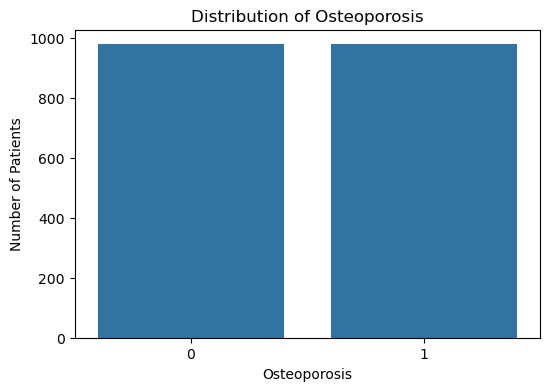

In [14]:
#Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Osteoporosis")

plt.title("Distribution of Osteoporosis")
plt.xlabel("Osteoporosis")
plt.ylabel("Number of Patients")

plt.show()

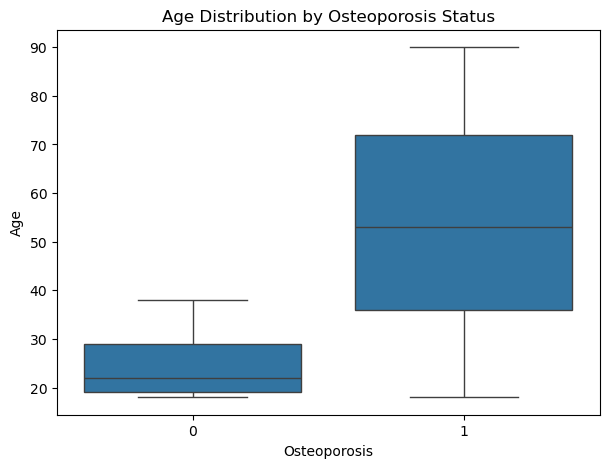

In [15]:
#Age vs Osteoporosis
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Osteoporosis", y="Age")

plt.title("Age Distribution by Osteoporosis Status")
plt.xlabel("Osteoporosis")
plt.ylabel("Age")

plt.show()

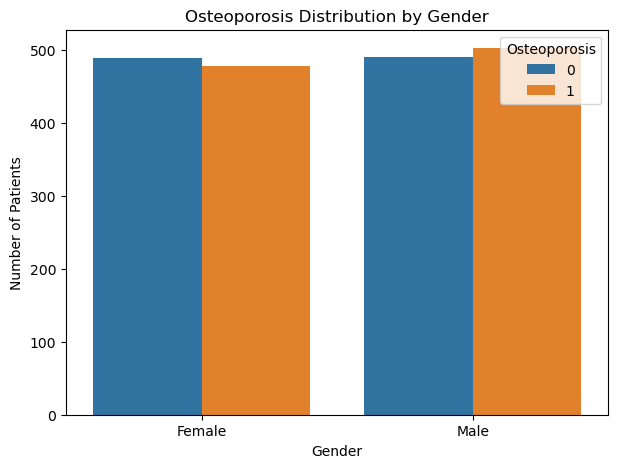

In [16]:
## Gender vs Osteoporosis
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Gender", hue="Osteoporosis")

plt.title("Osteoporosis Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

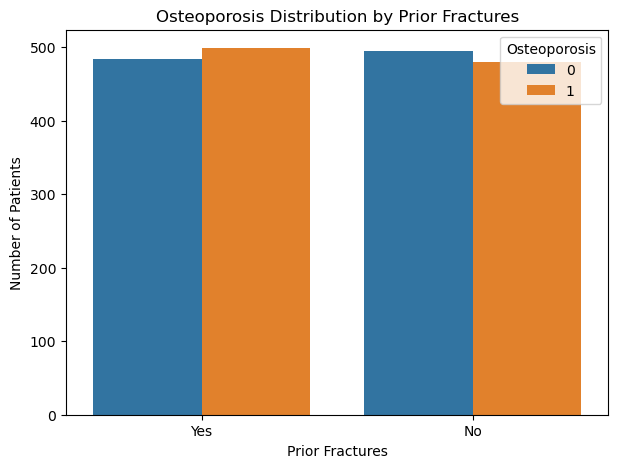

In [17]:
#Prior Fractures vs Osteoporosis
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Prior Fractures", hue="Osteoporosis")

plt.title("Osteoporosis Distribution by Prior Fractures")
plt.xlabel("Prior Fractures")
plt.ylabel("Number of Patients")

plt.show()

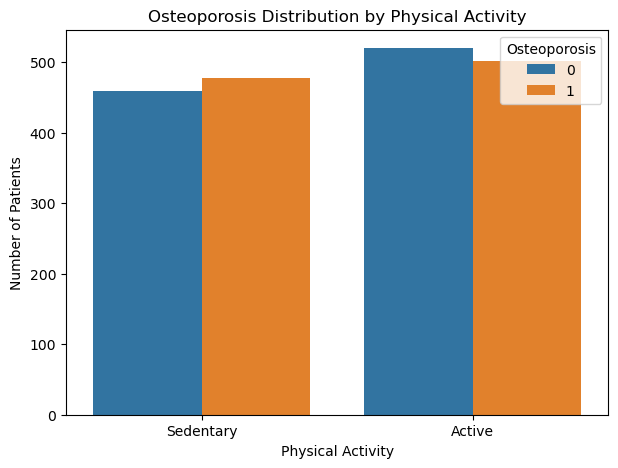

In [18]:
#Physical Activity vs vs Osteoporosis
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Physical Activity", hue="Osteoporosis")

plt.title("Osteoporosis Distribution by Physical Activity")
plt.xlabel("Physical Activity")
plt.ylabel("Number of Patients")

plt.show()

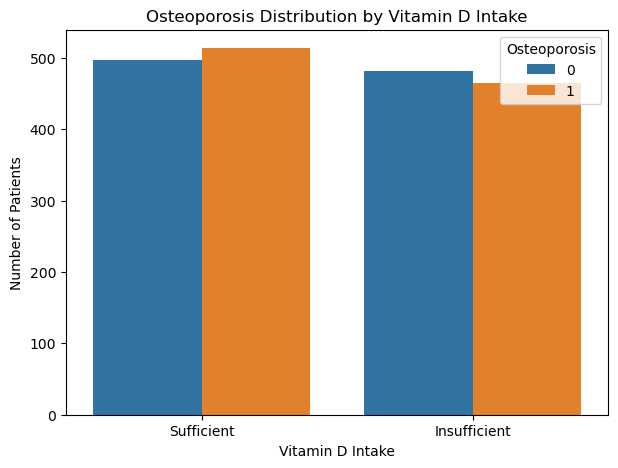

In [19]:
#vitamin D vs Osteoporosis
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Vitamin D Intake", hue="Osteoporosis")

plt.title("Osteoporosis Distribution by Vitamin D Intake")
plt.xlabel("Vitamin D Intake")
plt.ylabel("Number of Patients")

plt.show()

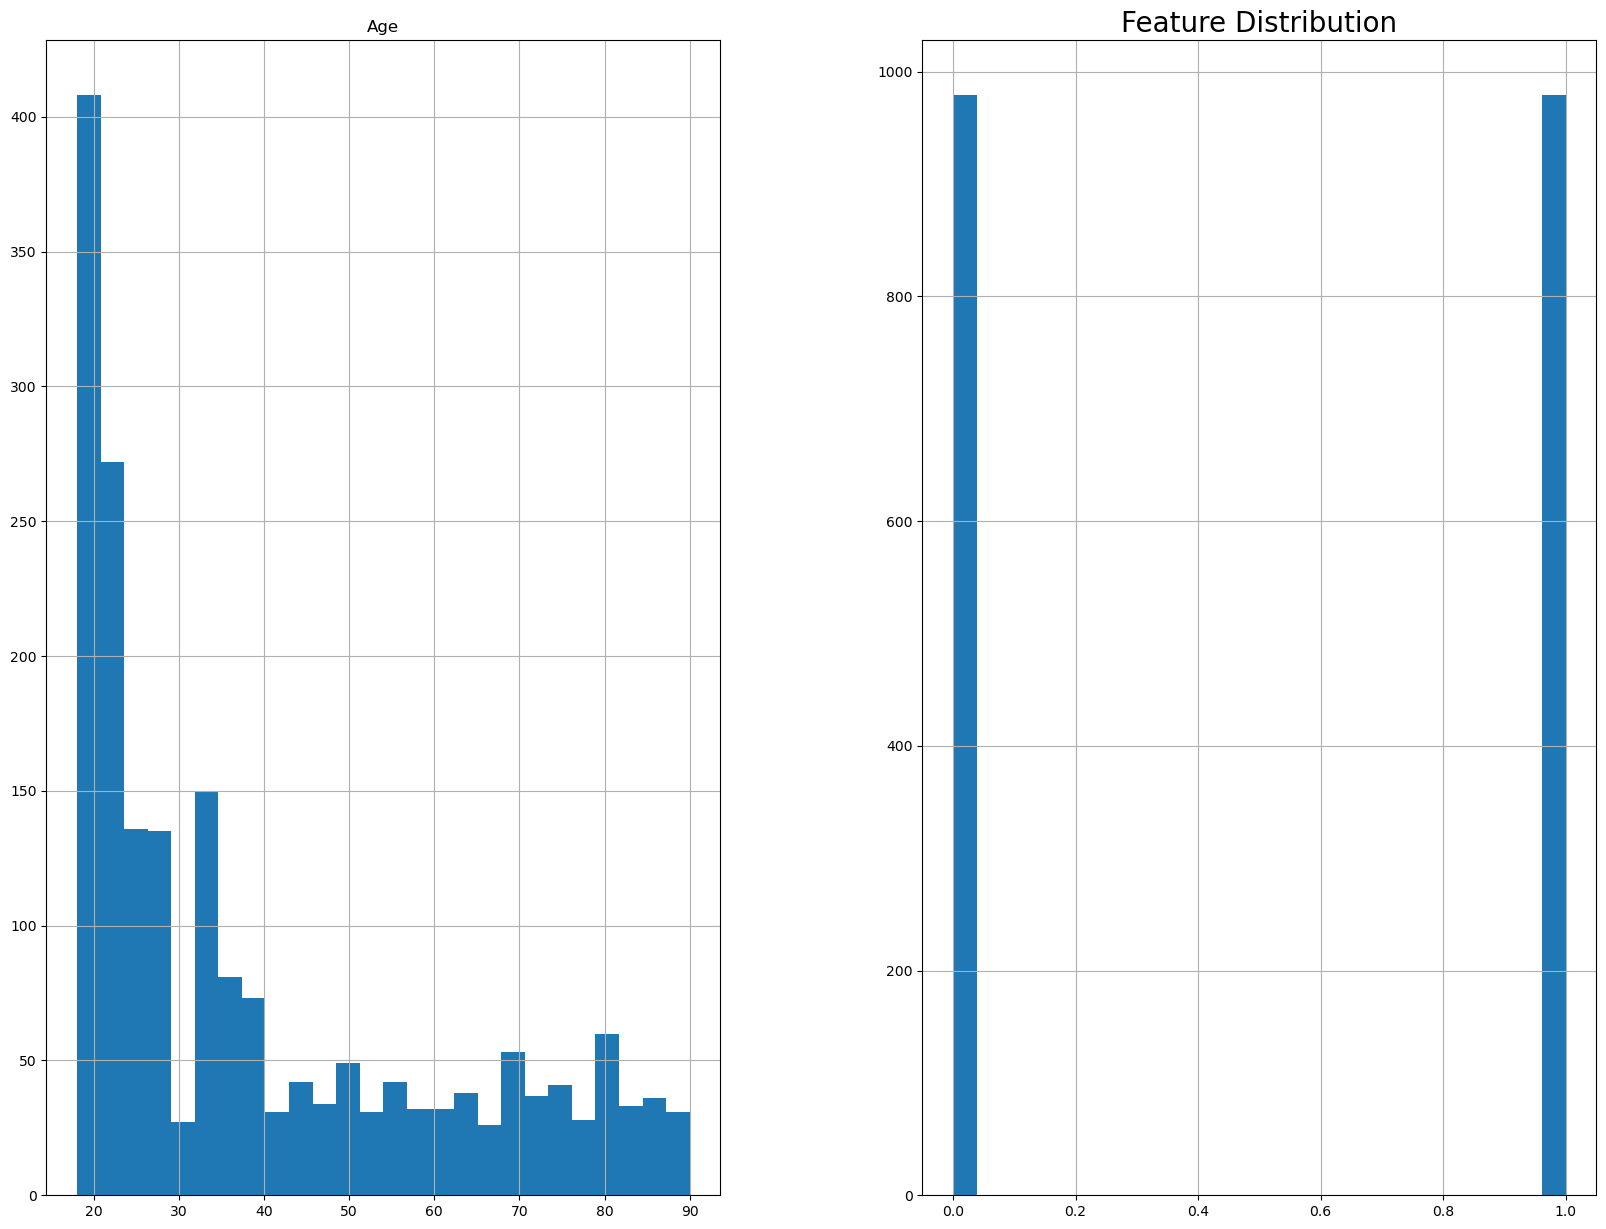

In [44]:
#Histogram
df.hist(figsize=(20,15),bins=26)

plt.title('Feature Distribution',fontsize=20)
plt.show()

## Define Features and Target

In [21]:
# Create a clean modeling dataset
df_model = df.copy()

# Define features and target
X = df_model.drop(columns=["Osteoporosis"])
y = df_model["Osteoporosis"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1958, 14)
Target shape: (1958,)


## Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [23]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1566, 14)
X_test: (392, 14)
y_train: (1566,)
y_test: (392,)


## Preprocessing Pipeline

In [24]:
# Identify numerical and categorical features
numerical_features = X_train.select_dtypes( include=["int64", "float64"] ).columns.tolist()
categorical_features = X_train.select_dtypes( include=["object"] ).columns.tolist()

print("Numerical features: ", numerical_features)
print("\nCategorical features: ", categorical_features)

Numerical features:  ['Age']

Categorical features:  ['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures']


In [25]:
preprocessor = ColumnTransformer(transformers=[("num",StandardScaler(),numerical_features),
                                               ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)])

## Models

In [26]:
#Define Initial Models
models = {"Logistic Regression": LogisticRegression(max_iter=2000),
          "Decision Tree": DecisionTreeClassifier(random_state=42),
          "Random Forest": RandomForestClassifier(n_estimators=200,random_state=42),
          "Gradient Boosting": GradientBoostingClassifier(random_state=42),
          "XGBoost": XGBClassifier(eval_metric="logloss",random_state=42) }

In [27]:
#Train Initial Models
initial_results = []
trained_models = {}
for name, model in models.items():
    pipeline = Pipeline(
        steps=[("preprocessor", preprocessor), ("model", model) ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    initial_results.append({"Model": name,"Accuracy": accuracy_score(y_test, y_pred),"Precision": precision_score(y_test, y_pred),
                            "Recall": recall_score(y_test, y_pred),"F1 Score": f1_score(y_test, y_pred),"ROC AUC": roc_auc_score(y_test, y_prob) })

    trained_models[name] = pipeline

initial_results_df = pd.DataFrame(initial_results)

initial_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Gradient Boosting,0.880102,0.986928,0.770408,0.865330,0.888744
4,XGBoost,0.859694,0.922156,0.785714,0.848485,0.888094
1,Decision Tree,0.811224,0.814433,0.806122,0.810256,0.811224
2,Random Forest,0.829082,0.927152,0.714286,0.806916,0.869039
0,Logistic Regression,0.808673,0.857988,0.739796,0.794521,0.879764


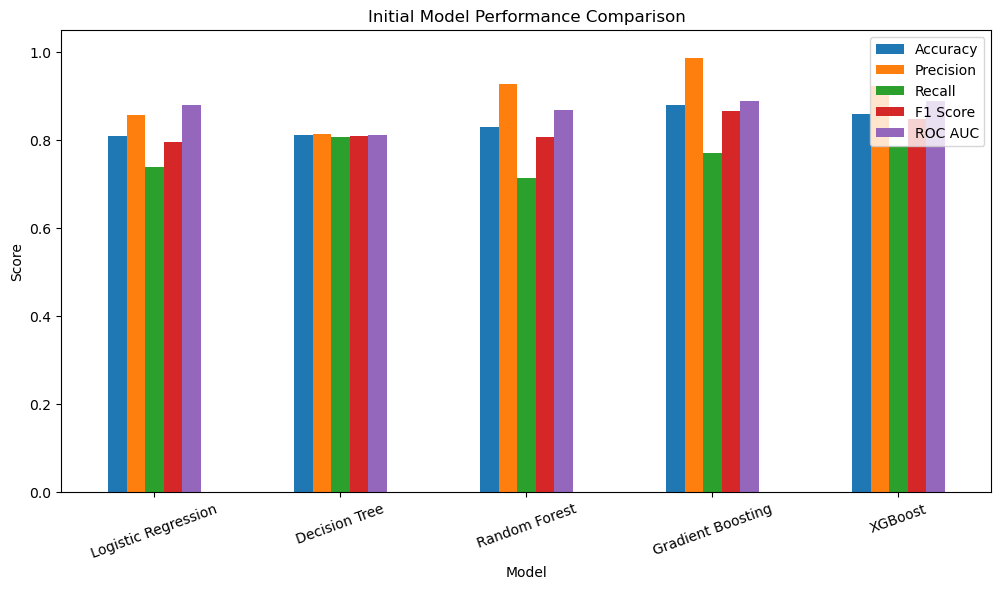

In [28]:
#Model Comparison Visual
initial_results_df.set_index("Model")[ ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"] ].plot(kind="bar", figsize=(12, 6) )

plt.title("Initial Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend()

plt.show()

## Hyperparameter Tuning

In [29]:
# Tune XGBoost
xgb_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", XGBClassifier(eval_metric="logloss",random_state=42)) ] )

xgb_params = {"model__n_estimators": [100, 200, 300], "model__max_depth": [3, 4, 5], "model__learning_rate": [0.01, 0.05, 0.1],
              "model__subsample": [0.8, 1.0], "model__colsample_bytree": [0.8, 1.0] }

xgb_grid = GridSearchCV(estimator=xgb_pipeline, param_grid=xgb_params, cv=5, scoring="f1", n_jobs=-1 )
xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters: ", xgb_grid.best_params_)
print("\nBest Cross-Validation F1:", xgb_grid.best_score_)

Best XGBoost Parameters:  {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 1.0}

Best Cross-Validation F1: 0.9086127836877024


In [30]:
#Tune Gradient Boosting
gb_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", GradientBoostingClassifier(random_state=42)) ] )

gb_params = {"model__n_estimators": [100, 200, 300], "model__learning_rate": [0.01, 0.05, 0.1], 
             "model__max_depth": [2, 3, 4], "model__subsample": [0.8, 1.0] }

gb_grid = GridSearchCV(estimator=gb_pipeline, param_grid=gb_params, cv=5, scoring="f1", n_jobs=-1 )
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters: ", gb_grid.best_params_)
print("\nBest Cross-Validation F1: ", gb_grid.best_score_)

Best Gradient Boosting Parameters:  {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 100, 'model__subsample': 0.8}

Best Cross-Validation F1:  0.914098174821601


In [31]:
# Tuned Model Comparison
tuned_results = pd.DataFrame({"Model": ["Gradient Boosting", "XGBoost"],
                              "CV F1 Score": [gb_grid.best_score_, xgb_grid.best_score_] })

tuned_results.sort_values(by="CV F1 Score", ascending=False)

,Model,CV F1 Score
0,Gradient Boosting,0.914098
1,XGBoost,0.908613


## Select Final Model

In [32]:
if gb_grid.best_score_ >= xgb_grid.best_score_:
    final_model = gb_grid.best_estimator_
    final_model_name = "Gradient Boosting"
else:
    final_model = xgb_grid.best_estimator_
    final_model_name = "XGBoost"

print("Final Model:", final_model_name)

Final Model: Gradient Boosting


## FINAL evaluation

In [33]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)
final_roc_auc = roc_auc_score(y_test, y_prob)

print("Final Model:", final_model_name)
print("-----------------------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC AUC  : {final_roc_auc:.4f}")

Final Model: Gradient Boosting
-----------------------------------
Accuracy : 0.8776
Precision: 0.9805
Recall   : 0.7704
F1 Score : 0.8629
ROC AUC  : 0.8871


## Final Classification Report

In [34]:
print(classification_report(y_test, y_pred, target_names=["No Osteoporosis","Osteoporosis"]) )

                 precision    recall  f1-score   support

No Osteoporosis       0.81      0.98      0.89       196
   Osteoporosis       0.98      0.77      0.86       196

       accuracy                           0.88       392
      macro avg       0.90      0.88      0.88       392
   weighted avg       0.90      0.88      0.88       392



## Final Confusion Matrix

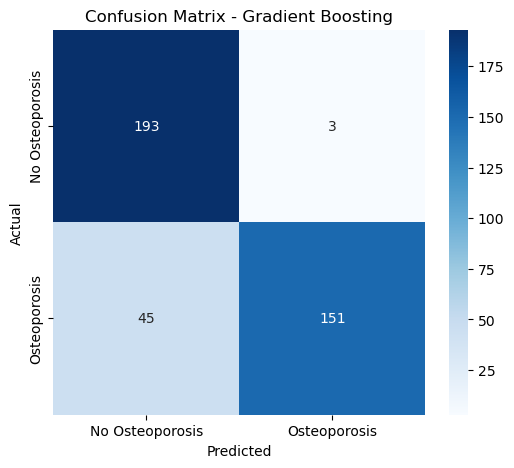

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Osteoporosis","Osteoporosis"],
             yticklabels=["No Osteoporosis","Osteoporosis"] )

plt.title(f"Confusion Matrix - {final_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Final ROC Curve

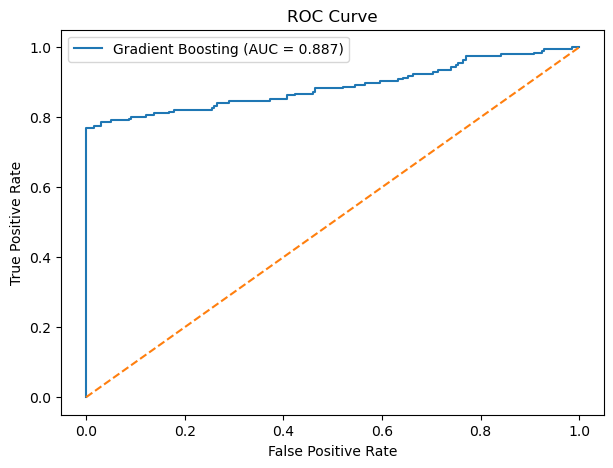

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{final_model_name} (AUC = {final_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Feature Importance

In [37]:
#table
final_preprocessor = final_model.named_steps["preprocessor"]
final_estimator = final_model.named_steps["model"]

feature_names = final_preprocessor.get_feature_names_out()
feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": final_estimator.feature_importances_ })
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance.head(15)

,Feature,Importance
0,num__Age,0.942251
24,cat__Medical Conditions_Rheumatoid Arthritis,0.004205
7,cat__Race/Ethnicity_African American,0.003983
11,cat__Body Weight_Underweight,0.003595
28,cat__Prior Fractures_Yes,0.003219
4,cat__Hormonal Changes_Postmenopausal,0.003219
9,cat__Race/Ethnicity_Caucasian,0.003136
27,cat__Prior Fractures_No,0.002580
6,cat__Family History_Yes,0.002551
25,cat__Medications_Corticosteroids,0.002432


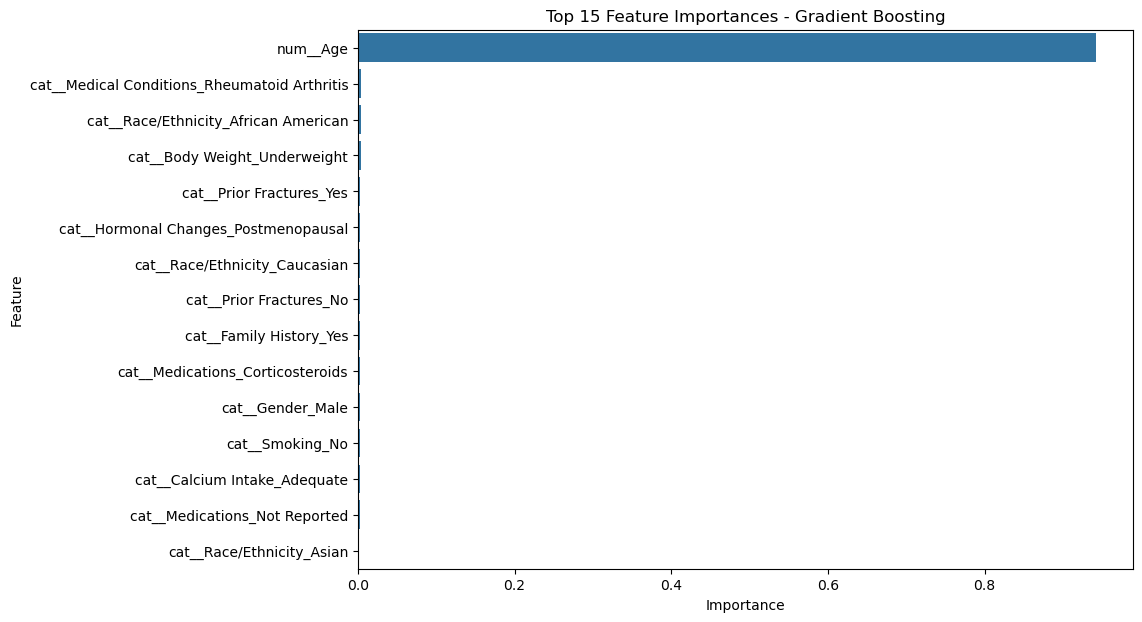

In [38]:
# Visual
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_features, x="Importance", y="Feature")

plt.title(f"Top 15 Feature Importances - {final_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Save the final model

In [39]:
joblib.dump(final_model, "osteoporosis_model.pkl")
print("Final model saved successfully.")

Final model saved successfully.


## Test the saved model

In [40]:
loaded_model = joblib.load("osteoporosis_model.pkl")

sample = X_test.iloc[[0]]
sample_prediction = loaded_model.predict(sample)[0]
sample_probability = loaded_model.predict_proba(sample)[0][1]

print("Prediction:", sample_prediction)
print("Probability:", sample_probability)

Prediction: 0
Probability: 0.0706250889491885


In [41]:
# Test the saved pipeline on a new, raw patient profile
new_patient = pd.DataFrame([{
    'Age': 68,
    'Gender': 'Female',
    'Hormonal Changes': 'Postmenopausal',
    'Family History': 'Yes',
    'Race/Ethnicity': 'Caucasian',
    'Body Weight': 'Underweight',
    'Calcium Intake': 'Low',
    'Vitamin D Intake': 'Insufficient',
    'Physical Activity': 'Sedentary',
    'Smoking': 'Yes',
    'Alcohol Consumption': 'Moderate',
    'Medical Conditions': 'Rheumatoid Arthritis',
    'Medications': 'Corticosteroids',
    'Prior Fractures': 'Yes'
}])

pred_prob = loaded_model.predict_proba(new_patient)[0, 1]
clinical_decision = "High Risk (Osteoporosis Screening Recommended)" if pred_prob >= 0.35 else "Low Risk"

print(f"Predicted Osteoporosis Probability: {pred_prob * 100:.2f}%")
print(f"Clinical Recommendation: {clinical_decision}")

Predicted Osteoporosis Probability: 99.20%
Clinical Recommendation: High Risk (Osteoporosis Screening Recommended)
